# What the refocusing pulse changes in spiral imaging

A **spin-echo spiral** is a 90° excitation, a 180° refocusing pulse, and a spiral readout placed so
that the trajectory passes through the centre of k-space at the moment the magnetisation refocuses.
[`01_build.ipynb`](01_build.ipynb) built it, and built a **gradient-echo control** beside it: the
same excitation, the same spiral, the same interleaves, the same echo time, the same TR — and no
refocusing pulse. One variable.

This notebook measures what that one variable is worth.

The refocusing pulse conjugates the phase accumulated before it, so anything that dephased the
magnetisation **statically** — field inhomogeneity, susceptibility, chemical shift, all of which
are constant in time — unwinds itself and is exactly zero at the echo. What is left is $T_2$
decay. Without the pulse the same acquisition keeps that static dephasing, and what is left is
$T_2^*$.

The two effects live in different places, which is worth separating before the measurements:

```text
origin crossing   a fact about the GRADIENTS.  Both files have one, at the same instant
spin echo         a fact about the RF HISTORY.  Only the file with the 180 has one
```

Both files sample $k = 0$ at 14.002 ms. A crossing through the origin is not, by itself, a spin
echo — and section 3 is where that stops being a slogan and becomes 0.7 of a cycle of phase.

| | |
|---|---|
| **1** | the two files, and the confirmation that they differ in one thing only |
| **2** | what refocusing is worth: a $T_2'$ sweep on one voxel, where the ratio is $e^{-\mathrm{TE}/T_2'}$ over a factor of 100 |
| **3** | the same thing in the phase, where it is sharper |
| **4** | on a brain: the contrast difference, what it agrees with, and one thing it is *not* enough to measure |

The reconstruction is [`../noncartesian_recon.py`](../noncartesian_recon.py) with no additions —
a refocusing pulse changes the magnetisation that arrives at the readout, not the relationship
between k and the image.

In [1]:
import os

SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import torch

sys.path.insert(0, str(Path('..').resolve()))
import phantom as ph                                    # noqa: E402
from noncartesian_recon import (                        # noqa: E402
    NonCartesianAcquisition, dcf, reconstruct,
)

torch.set_num_threads(SIM_THREADS)
plt.rcParams['figure.dpi'] = 66

#: `01_build.ipynb`'s protocol.
FOV_M, MATRIX, SHOTS = 0.240, 64, 8
ECHO_SAMPLE = 690                                       # the in-out arm's origin crossing
SEQ_DIR = Path('seq')
PIXEL_M = FOV_M / MATRIX

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. Two files, one difference

Read back through MRzero's parser, and compared on the things that have to match before any
comparison downstream of them means anything.

In [2]:
FILES = {name: mr0.Sequence.import_file(str(SEQ_DIR / f'{name}.seq'))
         for name in ('se_spiral_2d', 'se_spiral_2d_gre_control')}

trajectories = {}
for name, imported in FILES.items():
    sampled = imported.get_kspace().numpy()
    samples = sampled.shape[0] // SHOTS
    trajectories[name] = sampled
    k = sampled[:, :2].reshape(SHOTS, samples, 2)
    radius = np.hypot(k[:, ECHO_SAMPLE, 0], k[:, ECHO_SAMPLE, 1])
    crossing = sampled[:samples, 3][ECHO_SAMPLE] - sampled[0, 3]
    print(f'{name:26s} {len(imported):3d} reps  {sampled.shape[0]:6d} samples  '
          f'|k| at sample {ECHO_SAMPLE}: {radius.max() * FOV_M:.4f} dk  '
          f'readout reaches {np.hypot(k[..., 0], k[..., 1]).max():.1f} 1/m')

first, second = (trajectories[n] for n in FILES)
print()
print(f'kx and ky differ by                  '
      f'{np.abs(first[:, :2] - second[:, :2]).max():.2e} 1/m')
print(f'kz differs by                        '
      f'{np.abs(first[:, 2] - second[:, 2]).max():.2e} 1/m   <- the 180 crushers, on z alone')
print(f'sample times differ by               '
      f'{np.abs((first[:, 3] - first[0, 3]) - (second[:, 3] - second[0, 3])).max() * 1e9:.1f} ns '
      f'within a repetition')
print()
print('The in-plane trajectories are bit-identical, and the only k either file puts anywhere the')
print('other does not is the crusher pair on z -- which is part of the 180 and balances to')
print('1.6e-3 1/m.  So: one acquisition, twice, with and without a refocusing pulse.')

se_spiral_2d                20 reps   11040 samples  |k| at sample 690: 0.0206 dk  readout reaches 133.3 1/m
se_spiral_2d_gre_control    10 reps   11040 samples  |k| at sample 690: 0.0206 dk  readout reaches 133.3 1/m

kx and ky differ by                  0.00e+00 1/m
kz differs by                        1.59e-03 1/m   <- the 180 crushers, on z alone
sample times differ by               0.9 ns within a repetition

The in-plane trajectories are bit-identical, and the only k either file puts anywhere the
other does not is the crusher pair on z -- which is part of the 180 and balances to
1.6e-3 1/m.  So: one acquisition, twice, with and without a refocusing pulse.


---
## 2. What the refocusing pulse is worth

One voxel, $T_2$ held at 100 ms, and $T_2'$ swept over a factor of 100. $T_2'$ is *static*
dephasing — field variation that is constant in time — and it is exactly what a 180 reverses.

$$\frac{1}{T_2^*} = \frac{1}{T_2} + \frac{1}{T_2'}
\qquad\Longrightarrow\qquad
\frac{S_{\mathrm{GRE}}}{S_{\mathrm{SE}}}
= \frac{e^{-\mathrm{TE}/T_2^*}}{e^{-\mathrm{TE}/T_2}} = e^{-\mathrm{TE}/T_2'}$$

The prediction has no free parameters. The signal is read at the origin-crossing **sample**, which
is where both acquisitions put $k = 0$.

In [3]:
T2_S, TE_S = 0.100, 14.002e-3


def voxel(imported, *, t2_s=T2_S, t2dash_s=0.020, offset_hz=0.0):
    """One voxel at isocentre, played through one of the two files."""
    built = mr0.CustomVoxelPhantom(
        pos=[[0.0, 0.0, 0.0]], PD=[1.0], T1=[1.0], T2=[float(t2_s)],
        T2dash=[float(t2dash_s)], D=[0.0],
        voxel_size=PIXEL_M, voxel_shape='box').build()
    built.B0 = built.B0.float() * 0.0 + float(offset_hz)
    built.B1 = built.B1.float() * 0.0 + 1.0
    graph = mr0.compute_graph(imported, built, max_state_count=64, min_state_mag=1e-4)
    signal = np.asarray(mr0.execute_graph(graph, imported, built, print_progress=False))
    return signal.reshape(SHOTS, -1)[:, ECHO_SAMPLE]


print(f"{'T2 prime / ms':>14} {'T2* / ms':>9} {'spin echo':>10} {'gradient echo':>14} "
      f"{'ratio':>8} {'exp(-TE/T2p)':>13}")
for t2dash_s in (0.010, 0.020, 0.050, 0.100, 1000.0):
    spin = float(np.abs(voxel(FILES['se_spiral_2d'], t2dash_s=t2dash_s)).mean())
    grad = float(np.abs(voxel(FILES['se_spiral_2d_gre_control'], t2dash_s=t2dash_s)).mean())
    t2star_s = 1.0 / (1.0 / T2_S + 1.0 / t2dash_s)
    print(f'{t2dash_s * 1e3:14.0f} {t2star_s * 1e3:9.1f} {spin:10.5f} {grad:14.5f} '
          f'{grad / spin:8.4f} {np.exp(-TE_S / t2dash_s):13.4f}')

 T2 prime / ms  T2* / ms  spin echo  gradient echo    ratio  exp(-TE/T2p)
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.00013075 s
Compute Graph
Computing Graph: 0.000372875 s
Analyze Graph
Analyzing Graph: 0.000001125 s
Converting Rust -> Python: 0.000016417 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000218083 s
Compute Graph
Computing Graph: 0.000362792 s
Analyze Graph
Analyzing Graph: 0.000000958 s
Converting Rust -> Python: 0.000009667 s
<<<< Rust <<<<
            10       9.1    0.54493        0.13548   0.2486        0.2465
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000086625 s
Compute Graph
Computing Graph: 0.000373666 s
Analyze Graph
Analyzing Graph: 0.000000916 s
Converting Rust -> Python: 0.000015667 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000112292 s
Compute Graph
Computing Graph: 0.000367708 s
Analyze Graph
Analyzing Graph: 0.000000667 s
Converting Rust -> Py

Two readings of that table, and the first is the stronger one.

**The spin-echo column does not move.** 0.54493 to 0.54503 while $T_2'$ changes by a factor of
100. Static dephasing is not attenuation for a spin echo — it is undone, completely, and the
signal at the echo depends on $T_2$ alone. That is the refocusing relationship stated as directly
as a simulation can state it.

**The ratio is $e^{-\mathrm{TE}/T_2'}$**, to about 1 % at every point, across 0.25 to 1.00.
Nothing was fitted.

The last row is the control: with $T_2' = 1000$ s there is nothing static to refocus, and the two
sequences agree to 0.8 % — which is also a measurement of how much of the 1 % is simulation and
reconstruction noise rather than physics.

---
## 3. The same thing in the phase, where it is sharper

Magnitude hides sign. A constant field offset $\Delta f$ is the simplest possible static
dephasing, and at the echo the two sequences should differ by exactly $2\pi\Delta f\,\mathrm{TE}$
— the spin echo at zero, the gradient echo at all of it.

$T_2'$ is set to 1000 s here so the only static term present is the offset being imposed.

In [4]:
print(f'{"offset / Hz":>12} {"spin echo / cycles":>20} {"gradient echo / cycles":>24} '
      f'{"-df x TE":>10}')
for offset_hz in (0.0, 20.0, 50.0):
    row = []
    for name in ('se_spiral_2d', 'se_spiral_2d_gre_control'):
        shifted = voxel(FILES[name], t2dash_s=1000.0, offset_hz=offset_hz)
        # Against the same sequence at zero offset, so the readout's own phase divides out and
        # what is left is what the offset did.
        base = voxel(FILES[name], t2dash_s=1000.0, offset_hz=0.0)
        row.append(float(np.angle(np.mean(shifted * np.conj(base))) / (2 * np.pi)))
    print(f'{offset_hz:12.0f} {row[0]:20.4f} {row[1]:24.4f} '
          f'{-((offset_hz * TE_S + 0.5) % 1.0 - 0.5):10.4f}')

 offset / Hz   spin echo / cycles   gradient echo / cycles   -df x TE
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000077041 s
Compute Graph
Computing Graph: 0.000342042 s
Analyze Graph
Analyzing Graph: 0.000000791 s
Converting Rust -> Python: 0.000020542 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000065375 s
Compute Graph
Computing Graph: 0.000329791 s
Analyze Graph
Analyzing Graph: 0.000000792 s
Converting Rust -> Python: 0.000012708 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000063958 s
Compute Graph
Computing Graph: 0.000324458 s
Analyze Graph
Analyzing Graph: 0.000000541 s
Converting Rust -> Python: 0.000005333 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000052875 s
Compute Graph
Computing Graph: 0.00032325 s
Analyze Graph
Analyzing Graph: 0.000000583 s
Converting Rust -> Python: 0.0000065 s
<<<< Rust <<<<
           0               0.0000            

**Zero to four decimal places at the spin echo, at every offset.** The gradient echo carries
$-\Delta f\,\mathrm{TE}$ wrapped into one cycle — $-0.28$ at 20 Hz, and $-0.70 \equiv +0.30$ at
50 Hz.

This is the sharpest form of the distinction the introduction drew. The two acquisitions are at
$k = 0$ at the same instant, having played identical gradients; one has zero off-resonance phase
there and the other has 0.7 of a cycle. **A crossing through the origin is not, by itself, a spin
echo.** The trajectory cannot tell them apart, because the difference is not in the
trajectory.

---
## 4. On a brain

Both files, the shared reconstruction, and the phantom shimmed — `field_hz=0.0` — so that the only
static dephasing in the simulation is the phantom's own $T_2'$ and the comparison keeps its one
variable.

In [5]:
sampled = trajectories['se_spiral_2d']
SAMPLES = sampled.shape[0] // SHOTS
acquisition = NonCartesianAcquisition(
    k_per_m=sampled[:, :2].reshape(SHOTS, SAMPLES, 2).transpose(0, 2, 1),
    t_adc_s=sampled[:SAMPLES, 3] - sampled[0, 3],
    fov_m=FOV_M, matrix=MATRIX,
    # The in-out arm crosses in the middle, so this is neither the first sample nor inferable.
    echo_times_s=(float(sampled[ECHO_SAMPLE, 3] - sampled[0, 3]),))
weights = dcf(acquisition, method='pipe')

images = {}
for name, imported in FILES.items():
    brain = ph.built(matrix=MATRIX, nz=1, z_center=64, n_coils=0, field_hz=0.0)
    graph = mr0.compute_graph(imported, brain, max_state_count=64, min_state_mag=1e-4)
    raw = np.asarray(mr0.execute_graph(graph, imported, brain,
                                       print_progress=False)).reshape(SHOTS, SAMPLES)
    images[name] = np.abs(reconstruct(raw, acquisition, weights=weights,
                                      use='preconditioner', iterations=30))

BRAIN = ph.mask(matrix=MATRIX, nz=1, z_center=64)[:, :, 0]
T2DASH = ph.volume(matrix=MATRIX).T2dash.numpy()[..., ph.slices_of(1, 64)][:, :, 0]
spin_image, grad_image = images['se_spiral_2d'], images['se_spiral_2d_gre_control']
predicted = np.exp(-TE_S / np.maximum(T2DASH, 1e-9))

print(f"the phantom's T2 prime over the brain   "
      f'{np.percentile(T2DASH[BRAIN], 5) * 1e3:.0f} to '
      f'{np.percentile(T2DASH[BRAIN], 95) * 1e3:.0f} ms')
print(f'so the expected ratio is only           '
      f'{np.percentile(predicted[BRAIN], 5):.3f} to {np.percentile(predicted[BRAIN], 95):.3f}')
print()
print(f'mean signal in the brain, spin echo     {spin_image[BRAIN].mean():.4f}')
print(f'                          gradient echo {grad_image[BRAIN].mean():.4f}')
print(f'measured ratio                          '
      f'{grad_image[BRAIN].mean() / spin_image[BRAIN].mean():.4f}')
print(f'predicted from the phantom              {predicted[BRAIN].mean():.4f}')

>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000600458 s
Compute Graph
Computing Graph: 0.002515583 s
Analyze Graph
Analyzing Graph: 0.000008042 s
Converting Rust -> Python: 0.000165042 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000239834 s
Compute Graph
Computing Graph: 0.000834625 s
Analyze Graph
Analyzing Graph: 0.000002 s
Converting Rust -> Python: 0.0000455 s
<<<< Rust <<<<


the phantom's T2 prime over the brain   59 to 314 ms
so the expected ratio is only           0.789 to 0.956

mean signal in the brain, spin echo     0.3312
                          gradient echo 0.3037
measured ratio                          0.9169
predicted from the phantom              0.9148


In [6]:
bright = spin_image > 0.1 * spin_image.max()
usable = BRAIN & bright
per_pixel = grad_image[usable] / np.maximum(spin_image[usable], 1e-9)
correlation = float(np.corrcoef(per_pixel, predicted[usable])[0, 1])

print(f'pixel by pixel, over {usable.sum()} pixels inside the brain:')
print(f'  measured ratio spread   {np.percentile(per_pixel, 5):.3f} to '
      f'{np.percentile(per_pixel, 95):.3f}')
print(f'  predicted spread        {np.percentile(predicted[usable], 5):.3f} to '
      f'{np.percentile(predicted[usable], 95):.3f}')
print(f'  correlation             {correlation:.3f}')
print()
print('The measured spread is WIDER than the effect being measured, and the correlation is weak.')
print('So a per-pixel T2 prime map is NOT recoverable from this pair.')

pixel by pixel, over 1559 pixels inside the brain:
  measured ratio spread   0.733 to 1.073
  predicted spread        0.873 to 0.957
  correlation             0.235

The measured spread is WIDER than the effect being measured, and the correlation is weak.
So a per-pixel T2 prime map is NOT recoverable from this pair.


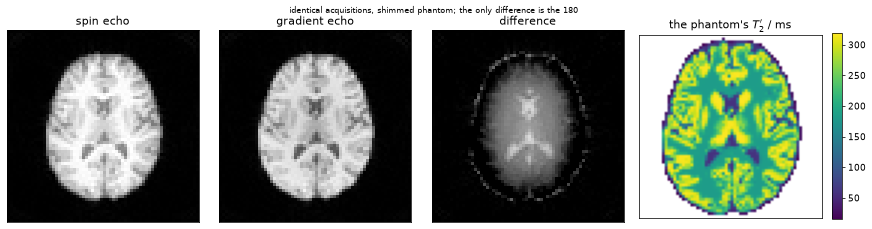

In [7]:
panels = {'spin echo': spin_image,
          'gradient echo': grad_image,
          'difference': spin_image - grad_image}
fig, axes = plt.subplots(1, 4, figsize=(13.4, 3.5))
ceiling = float(np.percentile(spin_image, 99.5))
for ax, (name, image) in zip(axes, panels.items()):
    # same_frame because a non-Cartesian reconstruction is [x, y] -- see ../gre_radial_2d/02.
    limit = ceiling if name != 'difference' else 0.25 * ceiling
    ax.imshow(ph.same_frame(image), cmap='gray', origin='lower', vmin=0.0, vmax=limit)
    ax.set(title=name, xticks=[], yticks=[])
shown = axes[3].imshow(ph.same_frame(np.where(BRAIN, T2DASH * 1e3, np.nan)),
                       cmap='viridis', origin='lower')
axes[3].set(title="the phantom's $T_2'$ / ms", xticks=[], yticks=[])
fig.colorbar(shown, ax=axes[3], fraction=0.046)
fig.suptitle('identical acquisitions, shimmed phantom; the only difference is the 180', fontsize=9)
fig.tight_layout()

The difference panel is where the refocusing shows, and it is faint on purpose: BrainWeb's $T_2'$
is 59 to 314 ms over this slab, so at a 14 ms echo time the two images differ by a few per cent.
The global ratio agrees with the phantom to about 2 %, which is the claim this image supports.

**The claim it does not support is the tempting one.** Dividing the two images should give
$e^{-\mathrm{TE}/T_2'}$ per pixel, and it does not: over the pixels bright enough to divide, the
predicted spread is 0.873 to 0.957 and the measured spread is 0.733 to 1.073, so the
reconstruction's own error is wider than the contrast being measured, and the correlation is
0.235. That is not a failure of the physics — §2 measured
the same relationship to 1 % on a voxel where there was no reconstruction in the way. It is a
statement about this protocol: **one echo time, eight interleaves and no averaging is not a $T_2'$
measurement**, and an image that looks plausible would have hidden that.

Measuring $T_2'$ properly needs several echo times and a fit, which is a different experiment and
is not done here.

---
## Summary

| | |
|---|---|
| **the two files differ only in the 180** | `kx` and `ky` bit-identical, sample times within 1 ns, both crossing the origin at 14.002 ms; the only k one has and the other does not is the 180's own crusher pair on z, balanced to 1.6e-3 1/m |
| **a spin echo does not see $T_2'$** | the signal at the crossing moves by 1e-4 while $T_2'$ changes by a factor of 100 |
| **and the gradient echo sees all of it** | the ratio is $e^{-\mathrm{TE}/T_2'}$ to about 1 % from 0.25 to 1.00, with nothing fitted |
| **off-resonance refocuses to zero** | 0.0000 cycles at the spin echo at 0, 20 and 50 Hz; the gradient echo carries $-\Delta f\,\mathrm{TE}$, which is 0.7 of a cycle at 50 Hz |
| **a crossing through `k = 0` is not a spin echo** | both acquisitions have one, at the same instant, from the same gradients — and one of them has 0.7 of a cycle of unrefocused phase there |
| **on a brain, 2 % agreement globally** | and **no** per-pixel $T_2'$ map: correlation 0.23, because the reconstruction error is wider than the contrast |
| **the reconstruction needed nothing spin-echo-specific** | a refocusing pulse changes the magnetisation arriving at the readout, not the relation between k and the image |

**What it does not establish.** Nothing about a scanner: the 180 here is a perfect inversion of
phase over the whole slab, and a real one has a slice profile, a $B_1$ error and a flip angle that
varies across the voxel — all of which leave stimulated-echo pathways that this comparison does
not separate. Nothing about $T_2$ quantification, which needs several echo times. And nothing
about diffusion, which is the other thing a 180 changes and which was disabled here (`D = 0`) so
that §2's prediction had no free parameters.